# Visualizing US Natural Disaster Declarations
## Milestone 1: Data Acquisition, Cleaning & Initial Exploration

This notebook performs:
- Data loading
- Data cleaning
- Initial exploratory data analysis
- Preliminary visualizations

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("DisasterDeclarationsSummaries.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (69634, 28)

Columns:
Index(['femaDeclarationString', 'disasterNumber', 'state', 'declarationType',
       'declarationDate', 'fyDeclared', 'incidentType', 'declarationTitle',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'incidentBeginDate', 'incidentEndDate',
       'disasterCloseoutDate', 'tribalRequest', 'fipsStateCode',
       'fipsCountyCode', 'placeCode', 'designatedArea',
       'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region',
       'designatedIncidentTypes', 'lastRefresh', 'hash', 'id'],
      dtype='str')


In [5]:
df.head()

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,0,0,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,0,0,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,0,0,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,0,0,...,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",0,0,...,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


**Data Cleaning**

In [6]:
# Convert date column
df['declarationDate'] = pd.to_datetime(df['declarationDate'], errors='coerce')
df['year'] = df['declarationDate'].dt.year
df = df.dropna(subset=['declarationDate', 'state', 'incidentType'])
df['incidentType'] = df['incidentType'].str.strip().str.title()
df['state'] = df['state'].str.strip().str.upper()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (69634, 29)


__EDA – Frequency Counts__

In [7]:
declarations_per_year = df['year'].value_counts().sort_index()

declarations_per_state = df['state'].value_counts()

declarations_per_year.head()

year
1953    13
1954    17
1955    18
1956    16
1957    16
Name: count, dtype: int64

In [8]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       disasterNumber    fyDeclared  ihProgramDeclared  iaProgramDeclared  \
count    69634.000000  69634.000000       69634.000000       69634.000000   
mean      2714.136370   2005.946391           0.167045           0.246819   
std       1437.694226     15.202781           0.373019           0.431164   
min          1.000000   1953.000000           0.000000           0.000000   
25%       1392.250000   1998.000000           0.000000           0.000000   
50%       3190.000000   2008.000000           0.000000           0.000000   
75%       4015.000000   2020.000000           0.000000           0.000000   
max       5621.000000   2026.000000           1.000000           1.000000   

       paProgramDeclared  hmProgramDeclared  tribalRequest  fipsStateCode  \
count       69634.000000       69634.000000   69634.000000   69634.000000   
mean            0.935621           0.431126       0.002398      31.394836   
std             0.245429           0.495237       0.04

**Plot – Time Series**

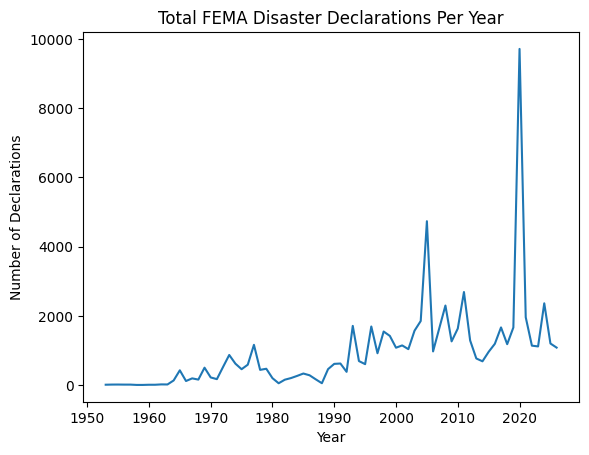

In [9]:
plt.figure()
declarations_per_year.plot(kind='line')
plt.title("Total FEMA Disaster Declarations Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.show()

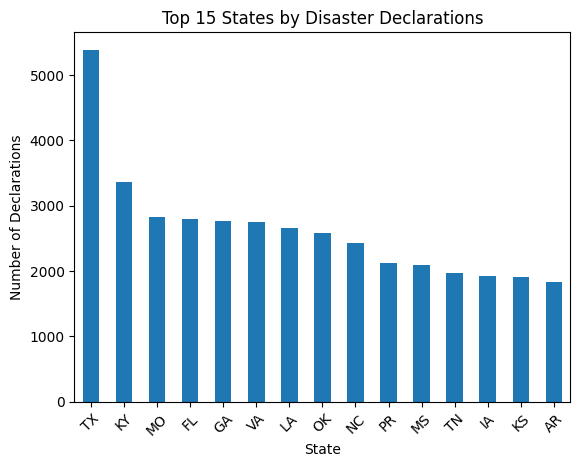

In [10]:
plt.figure()
declarations_per_state.head(15).plot(kind='bar')
plt.title("Top 15 States by Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Declarations")
plt.xticks(rotation=45)
plt.show()

# Milestone 2: Temporal Trend Visualization

## Refined Total Declarations Per Year

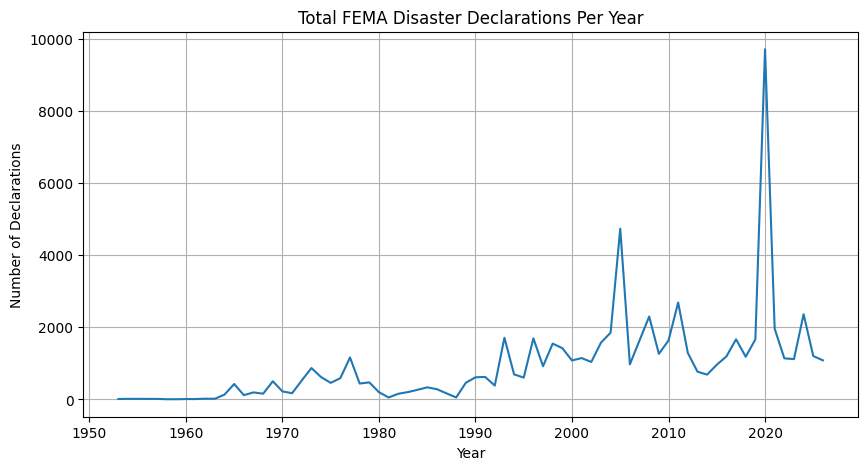

In [11]:
declarations_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(declarations_per_year.index, declarations_per_year.values)
plt.title("Total FEMA Disaster Declarations Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.grid(True)
plt.show()

## Trends of Major Incident Types Over Time (Multi-Line Chart)

<Figure size 1000x600 with 0 Axes>

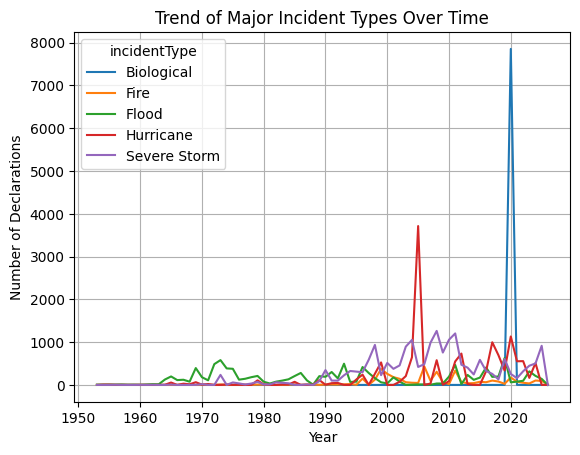

In [12]:
top_incidents = df['incidentType'].value_counts().head(5).index
df_top = df[df['incidentType'].isin(top_incidents)]

incident_trend = df_top.groupby(['year','incidentType']).size().unstack(fill_value=0)
plt.figure(figsize=(10,6))
incident_trend.plot()
plt.title("Trend of Major Incident Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.grid(True)
plt.show()

## Seasonality Analysis (Monthly Trends)

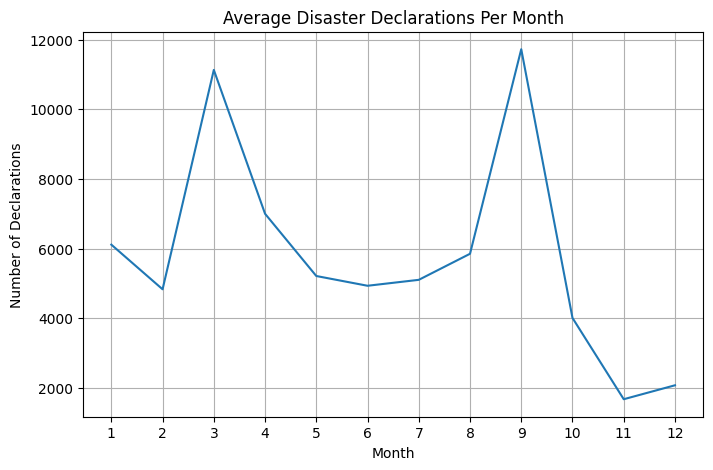

In [13]:
df['month'] = df['declarationDate'].dt.month

monthly_avg = df.groupby('month').size()

plt.figure(figsize=(8,5))
plt.plot(monthly_avg.index, monthly_avg.values)
plt.title("Average Disaster Declarations Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Declarations")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

## Incident Duration Trend

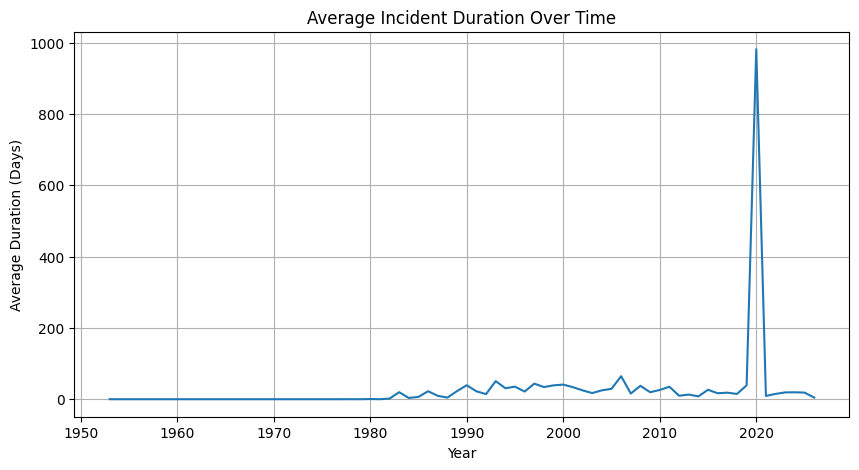

In [14]:
df['incidentBeginDate'] = pd.to_datetime(df['incidentBeginDate'], errors='coerce')
df['incidentEndDate'] = pd.to_datetime(df['incidentEndDate'], errors='coerce')

df['incidentDuration'] = (df['incidentEndDate'] - df['incidentBeginDate']).dt.days

duration_trend = df.groupby('year')['incidentDuration'].mean()

plt.figure(figsize=(10,5))
plt.plot(duration_trend.index, duration_trend.values)
plt.title("Average Incident Duration Over Time")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")
plt.grid(True)
plt.show()

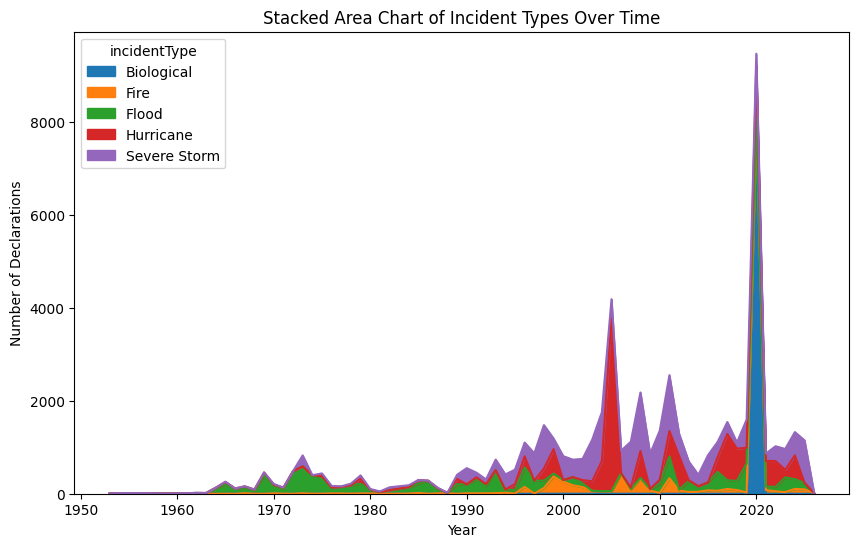

In [15]:
incident_trend.plot(kind='area', stacked=True, figsize=(10,6))
plt.title("Stacked Area Chart of Incident Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.show()

In [17]:
df.to_csv("fema_cleaned_data.csv", index=False)